# Software 1.0 — `deviation_score`

A hand-written, deterministic rule for an enterprise-IT host-health check. Each input is a
normalized absolute deviation from a metric's baseline (`0` = exactly normal, `1` = max
deviation). The score is the Euclidean distance from the all-normal point `(0, 0)`: `0` is
healthy, larger is more anomalous. You threshold it to fire an alert.

This is the Software 1.0 flavour: we wrote the rule, the test checks it, and a failing test is
a real regression.

In [1]:
def deviation_score(cpu_dev: float, mem_dev: float) -> float:
    """Combined anomaly magnitude for a host (distance from the all-normal point).

    Args:
        cpu_dev: normalized CPU deviation from baseline; valid range [0.0, 1.0].
        mem_dev: normalized memory deviation from baseline; valid range [0.0, 1.0].

    Returns:
        Euclidean distance from (0, 0): 0.0 = healthy, larger = more anomalous.
        Range [0.0, sqrt(2) ~= 1.41].
    """
    if not 0.0 <= cpu_dev <= 1.0:
        raise ValueError(f"cpu_dev must be in [0, 1], got {cpu_dev}")
    if not 0.0 <= mem_dev <= 1.0:
        raise ValueError(f"mem_dev must be in [0, 1], got {mem_dev}")
    return (cpu_dev**2 + mem_dev**2) ** 0.5

## Exact, reproducible tests

Same inputs, same output. Each assertion either holds or it doesn't — no wobble.

In [2]:
assert deviation_score(0.0, 0.0) == 0.0
assert deviation_score(0.6, 0.8) == 1.0
assert abs(deviation_score(0.6, 0.4) - 0.7211) < 1e-4

for bad in [(-0.1, 0.5), (0.5, 1.2)]:
    try:
        deviation_score(*bad)
    except ValueError as e:
        print("rejected:", e)

print("score(0.6, 0.4) =", round(deviation_score(0.6, 0.4), 4))

rejected: cpu_dev must be in [0, 1], got -0.1
rejected: mem_dev must be in [0, 1], got 1.2
score(0.6, 0.4) = 0.7211


## Picture it: a vector from the baseline

The two inputs are the legs of a right triangle; the score is the length of the hypotenuse —
the distance from the baseline `(0, 0)` to the point `(cpu_dev, mem_dev)`.

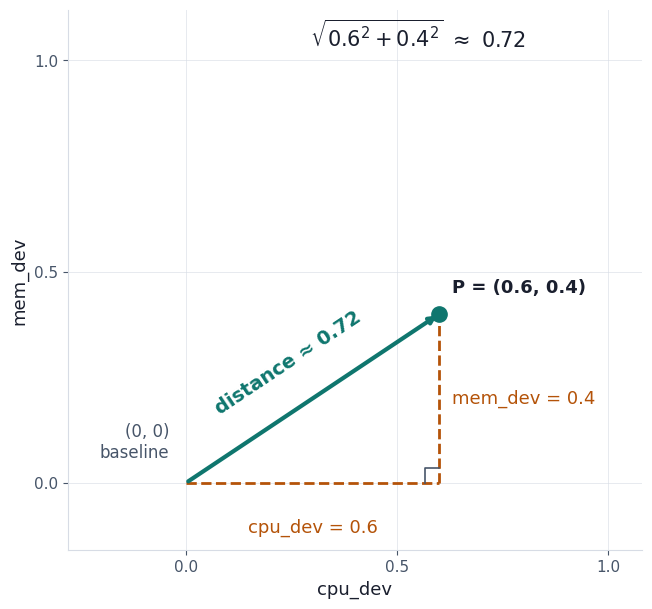

In [3]:
import math
import matplotlib.pyplot as plt

TXT, GRAY, TEAL, AMBER, GRID = "#1A1F2E", "#475569", "#0F766E", "#B45309", "#D7DCE5"
px, py = 0.6, 0.4
dist = deviation_score(px, py)
ang = math.degrees(math.atan2(py, px))

fig, ax = plt.subplots(figsize=(6.6, 6.2))
fig.patch.set_facecolor("white"); ax.set_facecolor("white")

ax.plot([0, px], [0, 0], "--", color=AMBER, lw=2)
ax.plot([px, px], [0, py], "--", color=AMBER, lw=2)
ax.plot([px-0.035, px-0.035, px], [0, 0.035, 0.035], color=GRAY, lw=1.2)

ax.annotate("", xy=(px, py), xytext=(0, 0),
            arrowprops=dict(arrowstyle="-|>", color=TEAL, lw=3))
ax.plot([px], [py], "o", color=TEAL, ms=11, zorder=5)

ax.text(px/2, -0.085, "cpu_dev = 0.6", color=AMBER, ha="center", va="top", fontsize=13)
ax.text(px+0.03, py/2, "mem_dev = 0.4", color=AMBER, ha="left", va="center", fontsize=13)
ax.text(px*0.5-0.045, py*0.5+0.065, f"distance \u2248 {dist:.2f}", color=TEAL,
        ha="center", va="bottom", fontsize=14, rotation=ang, rotation_mode="anchor", fontweight="bold")
ax.text(px+0.03, py+0.04, "P = (0.6, 0.4)", color=TXT, ha="left", va="bottom", fontsize=13, fontweight="bold")
ax.text(-0.04, 0.05, "(0, 0)\nbaseline", color=GRAY, ha="right", va="bottom", fontsize=12)
ax.text(0.55, 1.02, r"$\sqrt{0.6^2 + 0.4^2}\ \approx\ 0.72$", color=TXT, ha="center", va="bottom", fontsize=15)

ax.set_xlim(-0.28, 1.08); ax.set_ylim(-0.16, 1.12); ax.set_aspect("equal")
ax.set_xlabel("cpu_dev", color=TXT, fontsize=13); ax.set_ylabel("mem_dev", color=TXT, fontsize=13)
ax.set_xticks([0, 0.5, 1.0]); ax.set_yticks([0, 0.5, 1.0])
ax.tick_params(colors=GRAY, labelsize=11)
for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
for sp in ["left", "bottom"]: ax.spines[sp].set_color(GRID)
ax.grid(True, color=GRID, lw=0.7, alpha=0.6)
fig.tight_layout()
plt.show()

## The points we test

A good test set probes three kinds of input: **inside** the valid square (ordinary cases), **on the lines** — the boundary at 0 and 1, which the inclusive `[0, 1]` check must still accept — and **outside** `[0, 1]`, which the rule must *reject*. All of these are passing tests, so they are all green: round dots are valid inputs that score; green ✗ are out-of-range inputs where the correct behaviour is to raise `ValueError`.

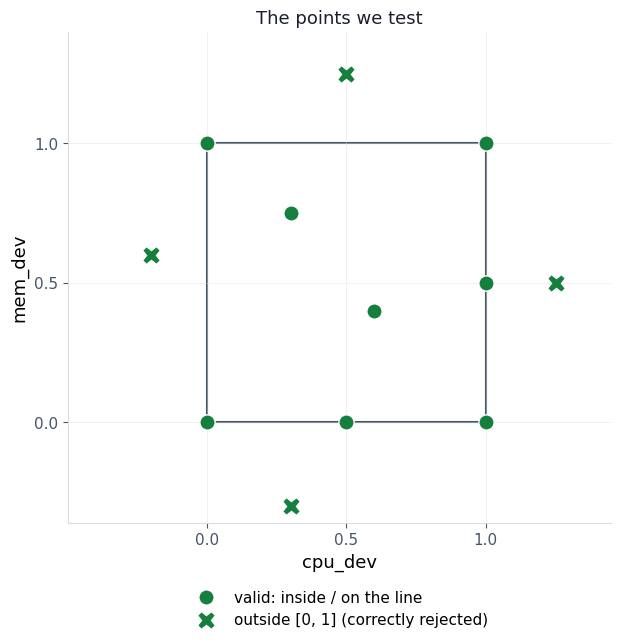

In [4]:
valid_pts = [(0.6, 0.4), (0.3, 0.75),
             (0.0, 0.0), (1.0, 1.0), (1.0, 0.0), (0.0, 1.0),
             (0.5, 0.0), (1.0, 0.5)]
outside_pts = [(1.25, 0.5), (-0.2, 0.6), (0.3, -0.3), (0.5, 1.25)]

from matplotlib.patches import Rectangle
GREEN, GREEN_FILL = "#15803D", "#86EFAC"

fig, ax = plt.subplots(figsize=(6.4, 6.2))
fig.patch.set_facecolor("white"); ax.set_facecolor("white")
ax.add_patch(Rectangle((0, 0), 1, 1, fill=False, edgecolor=GRAY, lw=1.5, zorder=1))
ax.plot([p[0] for p in valid_pts], [p[1] for p in valid_pts], "o", color=GREEN, ms=11,
        markeredgecolor="white", label="valid: inside / on the line", zorder=5)
ax.plot([p[0] for p in outside_pts], [p[1] for p in outside_pts], "X", color=GREEN, ms=13,
        markeredgecolor="white", label="outside [0, 1] (correctly rejected)", zorder=5)
ax.set_xlim(-0.5, 1.45); ax.set_ylim(-0.36, 1.4); ax.set_aspect("equal")
ax.set_xlabel("cpu_dev", fontsize=13); ax.set_ylabel("mem_dev", fontsize=13)
ax.set_xticks([0, 0.5, 1.0]); ax.set_yticks([0, 0.5, 1.0]); ax.tick_params(colors=GRAY, labelsize=11)
for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
for sp in ["left", "bottom"]: ax.spines[sp].set_color(GRID)
ax.grid(True, color=GRID, lw=0.6, alpha=0.5)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.11), frameon=False, fontsize=11)
ax.set_title("The points we test", color=TXT, fontsize=13)
fig.tight_layout(); plt.show()

## The assumption behind the tests

The tested points pass — colour them green. Here is the leap every test suite makes: from a handful of green points we assume the **entire space** is green, and we paint it green everywhere — even outside the square we actually tested. We never checked between the dots, or beyond them; we just trust the behaviour generalizes.

In Software 1.0 that trust is earned — an explicit, smooth formula. When the rule is *learned* or *rented*, the surface can be jagged and unknown, and a green dot can sit right next to a region that fails which you never sampled. That is when a passing test stops guaranteeing the space.

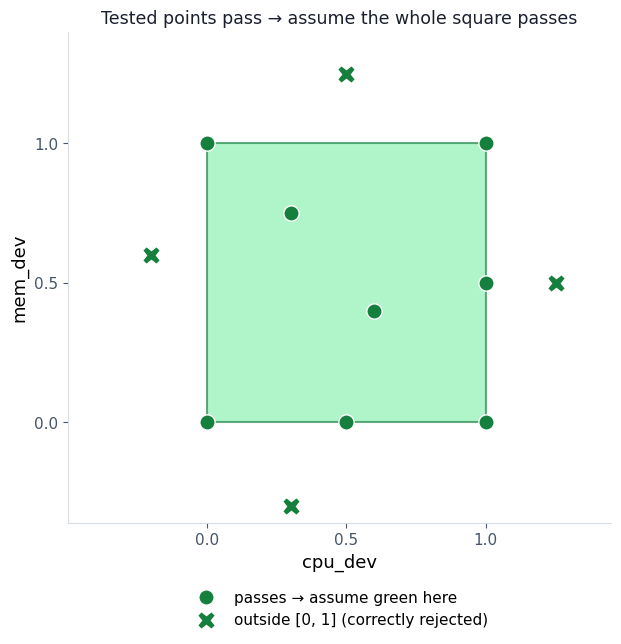

In [5]:
fig, ax = plt.subplots(figsize=(6.4, 6.2))
fig.patch.set_facecolor("white")
ax.set_xlim(-0.5, 1.45); ax.set_ylim(-0.36, 1.4); ax.set_aspect("equal")
ax.set_facecolor(GREEN_FILL)
ax.add_patch(Rectangle((0, 0), 1, 1, fill=False, edgecolor=GREEN, lw=1.5, zorder=2))
ax.plot([p[0] for p in valid_pts], [p[1] for p in valid_pts], "o", color=GREEN, ms=11,
        markeredgecolor="white", label="tested point (passes)", zorder=5)
ax.plot([p[0] for p in outside_pts], [p[1] for p in outside_pts], "X", color=GREEN, ms=13,
        markeredgecolor="white", label="outside [0, 1] (correctly rejected)", zorder=5)
ax.set_xlabel("cpu_dev", fontsize=13); ax.set_ylabel("mem_dev", fontsize=13)
ax.set_xticks([0, 0.5, 1.0]); ax.set_yticks([0, 0.5, 1.0]); ax.tick_params(colors=GRAY, labelsize=11)
for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
for sp in ["left", "bottom"]: ax.spines[sp].set_color(GRID)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.11), frameon=False, fontsize=11)
ax.set_title("We assume the whole space is green \u2014 even outside the square", color=TXT, fontsize=12.5)
fig.tight_layout(); plt.show()

## Why that assumption is safe here

We only *checked* a handful of points, yet we trust the score everywhere — because the rule is **smooth and known**. The surface below is the full `deviation_score` over every `(cpu_dev, mem_dev)`; the dots are our tested points. They sit on a known surface, so the green-everywhere assumption holds. This is the property that disappears once the rule is learned (SW 2.0) or rented (SW 3.0).

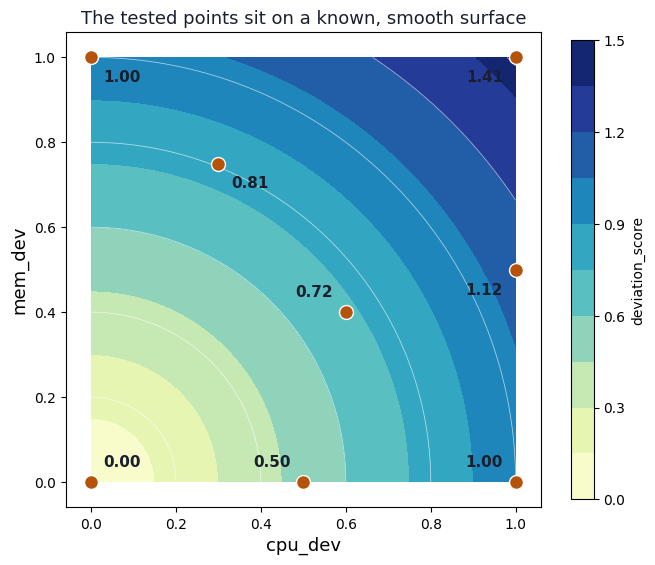

In [6]:
import numpy as np

g = np.linspace(0, 1, 240)
X, Y = np.meshgrid(g, g)
Z = np.sqrt(X**2 + Y**2)

fig, ax = plt.subplots(figsize=(6.8, 6.0))
fig.patch.set_facecolor("white"); ax.set_facecolor("white")
cf = ax.contourf(X, Y, Z, levels=12, cmap="YlGnBu")
ax.contour(X, Y, Z, levels=8, colors="white", linewidths=0.6, alpha=0.6)

for a, b in valid_pts:
    ax.plot(a, b, "o", color="#B45309", ms=10, markeredgecolor="white", zorder=5)
    dx, dy = (1 if a < 0.5 else -1), (1 if b < 0.5 else -1)
    ha = "left" if dx > 0 else "right"
    va = "bottom" if dy > 0 else "top"
    ax.annotate(f"{deviation_score(a, b):.2f}", (a, b), textcoords="offset points",
                xytext=(9 * dx, 9 * dy), ha=ha, va=va,
                color="#1A1F2E", fontsize=11, fontweight="bold", zorder=6)

ax.set_xlabel("cpu_dev", fontsize=13); ax.set_ylabel("mem_dev", fontsize=13)
ax.set_aspect("equal"); ax.set_xlim(-0.06, 1.06); ax.set_ylim(-0.06, 1.06)
fig.colorbar(cf, ax=ax, label="deviation_score", shrink=0.85)
ax.set_title("The tested points sit on a known, smooth surface", color="#1A1F2E", fontsize=13)
fig.tight_layout()
plt.show()

## Refactor + regression: which red is real?

Keep the behaviour, swap the implementation — `(cpu_dev**2 + mem_dev**2) ** 0.5` becomes `math.hypot`. Then re-run the recorded test cases. Watch what each assertion style does.

In [ ]:
import math

def deviation_score_hypot(cpu_dev, mem_dev):
    if not 0.0 <= cpu_dev <= 1.0:
        raise ValueError(f"cpu_dev must be in [0, 1], got {cpu_dev}")
    if not 0.0 <= mem_dev <= 1.0:
        raise ValueError(f"mem_dev must be in [0, 1], got {mem_dev}")
    return math.hypot(cpu_dev, mem_dev)

cases = [(0.0, 0.0), (0.6, 0.8), (1.0, 1.0), (0.6, 0.4), (1.0, 0.5), (0.3, 0.75)]

print("strict == regression (new vs golden from the **0.5 version):")
for a, b in cases:
    golden = deviation_score(a, b)
    new = deviation_score_hypot(a, b)
    status = "PASS" if new == golden else "FAIL"
    print(f"  ({a}, {b}): {status}   golden={golden!r}  new={new!r}")

print()
print("tolerance regression (math.isclose):")
for a, b in cases:
    golden = deviation_score(a, b)
    new = deviation_score_hypot(a, b)
    status = "PASS" if math.isclose(new, golden, rel_tol=1e-9, abs_tol=1e-12) else "FAIL"
    print(f"  ({a}, {b}): {status}")

### The implementation was fine — the tests were wrong

The two implementations agree to about `1e-16`; `math.hypot` is a correct, more robust way to compute the same distance. The strict `==` regression still flipped **red on `(0.6, 0.4)`** — purely a one-ULP floating-point difference, not a behaviour change.

So the defect was not the code. It was the **test**: an exact-equality assertion encodes an over-precise expectation that no correct refactor can keep satisfying. The fix is tolerance (`pytest.approx` / `math.isclose`), not reverting the change.

The lesson to carry forward: even in deterministic Software 1.0, a red is not always a real regression. Hold on to that instinct — it is exactly what gets stress-tested once the score becomes an estimate from a model.